In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
sales = pd.read_csv(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\Online_Sales.csv")
customers = pd.read_excel(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\CustomersData.xlsx")
coupon = pd.read_csv(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\Discount_Coupon.csv")
marketing = pd.read_csv(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\Marketing_Spend.csv")
tax = pd.read_excel(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\Tax_amount.xlsx")

In [3]:
for df in [sales, coupon, tax]:
    df.columns = (df.columns.str.strip().str.replace(' ', '_'))

In [4]:
sales['Transaction_Date'] = pd.to_datetime(sales['Transaction_Date'].astype(str), format = '%Y%m%d')

In [5]:
sales['Month'] = sales['Transaction_Date'].dt.strftime('%b')

In [6]:
sales['Product_Category'] = sales['Product_Category'].str.strip()
coupon['Product_Category'] = coupon['Product_Category'].str.strip()

sales = sales.merge(
    coupon,
    on=['Month','Product_Category'],
    how='left'
)

sales['Discount_pct'] = sales['Discount_pct'].fillna(0)

In [7]:
sales = sales.merge(
    tax,
    on='Product_Category',
    how='left'
)

In [8]:
sales['Invoice_Value'] = (
    (
        sales['Quantity']
        * sales['Avg_Price']
        * (1 - sales['Discount_pct']/100)
        * (1 + sales['GST']/100)
    )
    + sales['Delivery_Charges']
)

In [9]:
# Calculating RFM

In [10]:
snapshot_date = sales['Transaction_Date'].max() + pd.Timedelta(days=1)

In [11]:
rfm = sales.groupby('CustomerID').agg(
    Recency=('Transaction_Date',
             lambda x: (snapshot_date - x.max()).days),

    Frequency=('Transaction_ID','nunique'),

    Monetary=('Invoice_Value','sum')
).reset_index()

In [12]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

In [13]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

In [14]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [15]:
rfm['RFM_Total'] = (
    rfm['R_Score'].astype(int)
    +
    rfm['F_Score'].astype(int)
    +
    rfm['M_Score'].astype(int)
)

In [16]:
def segment(score):

    if score >= 10:
        return 'Premium'

    elif score >= 8:
        return 'Gold'

    elif score >= 5:
        return 'Silver'

    else:
        return 'Standard'

In [17]:
rfm['Segment'] = rfm['RFM_Total'].apply(segment)

In [18]:
rfm['Segment'].value_counts()

Segment
Silver      510
Premium     408
Gold        313
Standard    237
Name: count, dtype: int64

In [19]:
rfm.groupby('Segment')['Monetary'].sum()

Segment
Gold        9.472310e+05
Premium     2.748182e+06
Silver      5.370088e+05
Standard    7.317962e+04
Name: Monetary, dtype: float64

In [20]:
rfm

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total,Segment
0,12346,108,1,171.725887,3,1,1,5,Silver
1,12347,60,31,10632.890268,3,4,4,11,Premium
2,12348,74,8,1341.274742,3,2,2,7,Silver
3,12350,18,11,1080.966849,4,2,2,8,Gold
4,12356,108,13,1648.281319,3,3,3,9,Gold
...,...,...,...,...,...,...,...,...,...
1463,18259,271,3,770.459148,1,1,2,4,Standard
1464,18260,88,19,2434.410793,3,3,3,9,Gold
1465,18269,195,2,140.122949,2,1,1,4,Standard
1466,18277,70,1,274.468200,3,1,1,5,Silver


In [21]:
# Scientific Segmentation

In [22]:
kmeans_data = rfm[
    ['Recency','Frequency','Monetary']
]

In [23]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    kmeans_data
)

In [24]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

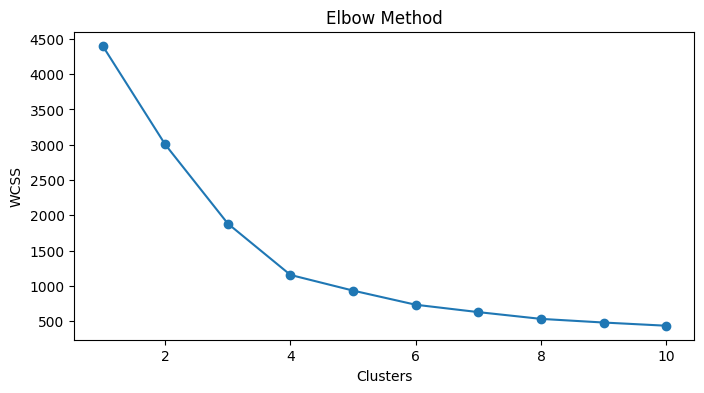

In [25]:
plt.figure(figsize=(8,4))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel('Clusters')
plt.ylabel('WCSS')

plt.title('Elbow Method')
plt.show()

In [26]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(
    scaled_data
)

e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [27]:
cluster_profile = rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean'),
    Customers=('CustomerID','count')
)

cluster_profile

,Avg_Recency,Avg_Frequency,Avg_Monetary,Customers
Cluster,,,,
0,255.172727,10.294545,1574.404650,550
1,78.695238,12.839456,1944.598949,735
2,81.833333,270.666667,53059.966194,6
3,82.553672,55.977401,9559.543873,177


In [31]:
cluster_map = {
    2: 'Premium',
    3: 'Gold',
    1: 'Silver',
    0: 'Standard'
}

rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_map)

In [32]:
rfm['Cluster_Name'].value_counts()

Cluster_Name
Silver      735
Standard    550
Gold        177
Premium       6
Name: count, dtype: int64

In [33]:
rfm.groupby('Cluster_Name').agg(
    Customers=('CustomerID','count'),
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean')
)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster_Name,,,,
Gold,177,82.553672,55.977401,9559.543873
Premium,6,81.833333,270.666667,53059.966194
Silver,735,78.695238,12.839456,1944.598949
Standard,550,255.172727,10.294545,1574.404650


In [34]:
rfm.to_csv(
    'customer_segmentation.csv',
    index=False
)

In [35]:
final_segments = rfm[
    ['CustomerID',
     'Segment',
     'Cluster',
     'Cluster_Name']
]

final_segments.to_csv(
    'customer_segments_final.csv',
    index=False
)

In [36]:
cluster_summary = rfm.groupby('Cluster_Name').agg(
    Customers=('CustomerID','count'),
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean')
)

cluster_summary.to_csv(
    'cluster_summary.csv'
)